In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)

from functools import partial

# timing and progress bars
from timeit import default_timer as timer
from tqdm import tqdm

# numerics
import jax
import jax.numpy as jnp
from jax import jit
import jax.random as jr

import optimistix as optx
import equinox as eqx
import optax
from flax.training.checkpoints import save_checkpoint


from flow_CrossAttentionSetTransformer import Flow
from dataloader import OdisseoOTAllParametersPosition_newprior
from sampling_time import sample_time


In [2]:
dataloader_train = OdisseoOTAllParametersPosition_newprior(
            DATA_ROOT = '/export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior',
            # replacement = True,
            num_samples = 100_000,
            split= [0, 94999],
            seed= 0,
            num_steps = 2000,
            batch_size = 256,
            use_jax = False,
            use_log = True,)

dataloader_val = OdisseoOTAllParametersPosition_newprior(
            DATA_ROOT = '/export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior',
            num_samples= 100_000,
            split= [95000, 99999],
            seed= 0,
            num_steps= 1000,
            batch_size= 256,
            use_jax = False, 
            use_log=True)

odisseo_AllParametersPosition_newprior
DATA_ROOT: /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior/
Loading odisseo_AllParametersPosition_newprior locally from existing directory /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior
using numpy to load
using numpy to load
Dataloader sampling without replacements (num_steps: 372)
odisseo_AllParametersPosition_newprior
DATA_ROOT: /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior/
Loading odisseo_AllParametersPosition_newprior locally from existing directory /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior
using numpy to load
using numpy to load
Dataloader sampling without replacements (num_steps: 20)


In [3]:
# ============================
# Initialization
# ============================

SEED = 42
dim_flow = 13
N_dim = 64
N_head = 1
depth = 2
key = jax.random.PRNGKey(SEED)
key, subkey = jax.random.split(key, 2)
flow = Flow(dim_flow=dim_flow,
            N_dim=N_dim,
            N_head=N_head, 
            depth=depth, 
            sample_size=1000,
            ln=False,)

flow_params = flow.init_weights(subkey)


# ============================
# Loss function
# ============================

@jit
def loss_fn(flow_params, rng, batch):
    # v_pred = flow.apply({'params': flow_params}, timesteps=t, sample=theta, encoder_hidden_states=x_obs)
    # loss = jnp.mean((v_pred - v_target) ** 2)
    # return loss

    sigma_min = 0.0001

    time_alpha = 0.0

    # sample time
    t, rng = sample_time(rng, batch["parameters"].shape[0],
                            t0=0.0, t1=1.0,
                            alpha=time_alpha, eps=0.0)
    
    # sample noise
    epsilon = jr.normal(rng, shape=batch["parameters"].shape)
    noise = jnp.einsum("ab,a->ab", epsilon, (1 - (1-sigma_min) * t))

    # get x_t
    mu_x = jnp.einsum('a, ab->ab', t, batch["parameters"])
    theta_t = mu_x + noise

    # prediction of flow
    flow_prediction = flow.apply({'params': flow_params},
                                    timesteps=jnp.expand_dims(t, axis=1), 
                                    sample=theta_t,
                                    encoder_hidden_states=batch["conditioning"],)
    
    target = batch['parameters'] - (1-sigma_min) * epsilon

    loss = jnp.mean((target - flow_prediction) ** 2, axis=1)

    return jnp.mean(loss)



# ============================
# Optimizer
# ============================

learning_rate = 1e-3
optimizer = optax.adamw(learning_rate)
opt_state = optimizer.init(flow_params)

# ============================
# Training step
# ============================

@eqx.filter_jit
def train_step(flow_params, opt_state, rng, batch ):
    """
    Performs one optimization step.
    """
    
    loss_value, grads = jax.value_and_grad(loss_fn)(
        flow_params, rng, batch
    )

    updates, opt_state = optimizer.update(grads, opt_state, flow_params)
    flow_params = optax.apply_updates(flow_params, updates)
    return flow_params, opt_state, loss_value

# ============================
# Training loop
# ============================

print("Starting training with optax...")
training_loss = []
val_loss = []
n_epoch = 50

trained_params = flow_params
best_loss = float('inf')
best_params = trained_params

start_time = timer()
pbar = tqdm(range(n_epoch))


for epoch in pbar:
    epoch_training_loss = 0.0
    for batch_train_idx, batch in enumerate(dataloader_train):

        key, subkey = jax.random.split(key)
        trained_params, opt_state, loss_value = train_step(
            trained_params, opt_state,key, batch )
        
        epoch_training_loss += loss_value.item()

    epoch_val_loss = 0.0
    for batch_val_idx, batch in enumerate(dataloader_val):
        
        key, subkey = jax.random.split(key)
    
        val_loss_batch = loss_fn(flow_params, key, batch)
        
        epoch_val_loss += val_loss_batch.item()

    epoch_training_loss /= (batch_train_idx + 1)
    training_loss.append(epoch_training_loss)
    epoch_val_loss /= (batch_val_idx + 1)
    val_loss.append(epoch_val_loss)

    pbar.set_description(f"Epoch {epoch+1}, Loss: {epoch_training_loss:.6f}, Val Loss: {epoch_val_loss:.6f}", )

    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        best_params = trained_params
        print(f"New best model found at epoch {epoch+1} with val loss {best_loss:.6f}")


Starting training with optax...


Epoch 1, Loss: 1.415452, Val Loss: 2.002374:   2%|▏         | 1/50 [01:25<1:10:07, 85.87s/it]

New best model found at epoch 1 with val loss 2.002374


Epoch 2, Loss: 1.110395, Val Loss: 1.988604:   4%|▍         | 2/50 [02:27<57:06, 71.38s/it]  

New best model found at epoch 2 with val loss 1.988604


Epoch 8, Loss: 0.904525, Val Loss: 1.982600:  16%|█▌        | 8/50 [08:41<44:07, 63.04s/it]

New best model found at epoch 8 with val loss 1.982600


Epoch 50, Loss: 1.679301, Val Loss: 2.007213: 100%|██████████| 50/50 [51:47<00:00, 62.15s/it]


In [ ]:
file_path = save_checkpoint('/export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/', target=best_params, step=1, )
print(f"Model saved at {file_path}")

Model saved at /export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/checkpoint_0


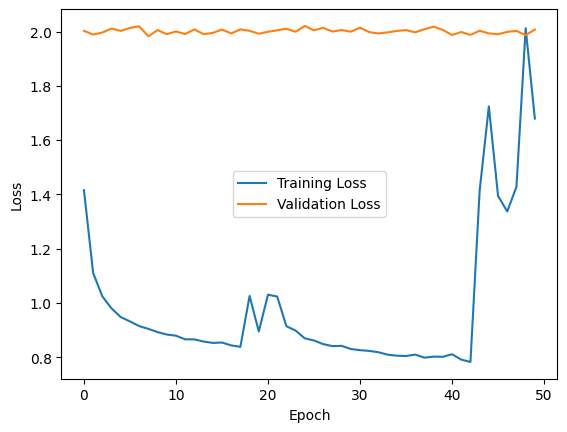

In [5]:
import matplotlib.pyplot as plt
plt.plot(training_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# ============================
# Flow model definition
# ============================

# use gated linear units, such that each layer in the
# net is conditioned on theta and t while x is the main input

# class GLULayer(eqx.Module):
#     lin_x: eqx.nn.Linear    # processes x
#     lin_gate: eqx.nn.Linear # processes (theta, t)

#     def __init__(self, dim_x, dim_theta_t, out_dim, key):
#         key1, key2 = jax.random.split(key)
#         self.lin_x = eqx.nn.Linear(dim_x, out_dim, key=key1)
#         self.lin_gate = eqx.nn.Linear(dim_theta_t, out_dim, key=key2)

#     def __call__(self, x, theta_t):
#         # x-stream
#         h_x = self.lin_x(x)
#         # gating stream
#         gate = jax.nn.sigmoid(self.lin_gate(theta_t))
#         # gated output
#         return h_x * gate


# class Flow(eqx.Module):
#     layers: list
#     final: eqx.nn.Linear

#     def __init__(self, dim_theta, dim_x, key, h: int = 512, depth: int = 3):
#         keys = jax.random.split(key, depth + 1)
#         self.layers = [
#             GLULayer(dim_x if i == 0 else h, dim_theta + 1, h, keys[i])
#             for i in range(depth)
#         ]
#         self.final = eqx.nn.Linear(h, dim_theta, key=keys[-1])

#     def __call__(self, theta, x, t):
#         t = jnp.atleast_1d(t)
#         theta_t = jnp.concatenate([theta, t], axis=-1)
#         out = x
#         for layer in self.layers:
#             out = layer(out, theta_t)
#         return self.final(out)


# ============================
# Loss function
# ============================

@eqx.filter_jit
def loss_fn(flow_params, theta, x_obs, t, v_target):
    flow_model = eqx.combine(flow_params, flow_architecture)
    v_pred = jax.vmap(flow_model)(theta, x_obs, t)
    loss = jnp.mean((v_pred - v_target) ** 2)
    return loss

# ============================
# Optimizer
# ============================

learning_rate = 1e-3
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(flow_params)

# ============================
# Training step
# ============================

@eqx.filter_jit
def train_step(flow_params, opt_state, source_theta, target_theta, x_obs, time):
    """
    Performs one optimization step.
    """
    v_target = target_theta - source_theta
    theta_eval = source_theta + v_target * time

    sigma_min = 0.01

    # from the reference papers, for optimal transport gaussian paths
    # v_target = (target_theta - (1 - sigma_min) * theta_eval) / (1 - (1 - sigma_min) * time)

    loss_value, grads = eqx.filter_value_and_grad(loss_fn)(
        flow_params, theta_eval, x_obs, time, v_target
    )
    updates, opt_state = optimizer.update(grads, opt_state, flow_params)
    flow_params = eqx.apply_updates(flow_params, updates)
    return flow_params, opt_state, loss_value

# ============================
# Training loop
# ============================

print("Starting training with optax...")
num_steps = 9000
batch_size = 1024
losses = []

trained_params = flow_params
best_loss = float('inf')
best_params = trained_params

start_time = timer()
pbar = tqdm(range(num_steps))

for step in pbar:

    key, sk1, sk2, sk3 = jax.random.split(key, 4)

    # start from standard normal
    source_theta = jax.random.normal(sk1, (batch_size, 4))

    # theta from prior
    target_theta = jax.random.normal(sk2, (batch_size, 4)) * jnp.sqrt(sigma2_theta) + mu_theta

    # corresponding observations
    x_obs = jax.vmap(theoretical_observation)(target_theta)

    # while x_obs contains any nans, resample
    while jnp.isnan(x_obs).any():
        key, sk1, sk2, sk3 = jax.random.split(key, 4)
        target_theta = jax.random.normal(sk2, (batch_size, 4)) * jnp.sqrt(sigma2_theta) + mu_theta
        x_obs = jax.vmap(theoretical_observation)(target_theta)

    time = jax.random.uniform(sk3, (batch_size, 1))

    trained_params, opt_state, loss = train_step(
        trained_params, opt_state, source_theta, target_theta, x_obs, time
    )

    losses.append(loss)

    # removed best params logic, does not
    # make sense in this context, I think
    best_params = trained_params

    pbar.set_description(f"Step {step+1}/{num_steps} | Loss: {loss:.2e}")

trained_params = best_params
end_time = timer()
print(f"Training finished in {end_time - start_time:.2f} seconds.")

# Combine trained params and architecture into a callable flow model
flow_model = eqx.combine(trained_params, flow_architecture)
flow_model = jax.vmap(flow_model)

# Midpoint RK2 stepper for one time step
def rk2_step_flow(theta, x_obs, t, dt):
    v1 = flow_model(theta, x_obs, jnp.full((theta.shape[0], 1), t))
    mid_theta = theta + 0.5 * dt * v1
    v2 = flow_model(mid_theta, x_obs, jnp.full((theta.shape[0], 1), t + 0.5 * dt))
    return theta + dt * v2